In [2]:
!rm -rf RePaint
!git clone https://github.com/andreas128/RePaint.git
%cd RePaint


!mkdir -p my_samples/imgs my_samples/masks checkpoints outputs


Cloning into 'RePaint'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 85 (delta 42), reused 26 (delta 26), pack-reused 35 (from 1)
Receiving objects: 100% (85/85), 49.88 KiB | 16.63 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/RePaint


In [3]:

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


!pip install -q einops pyyaml pillow scikit-image tqdm matplotlib opencv-python


!pip install -q hydra-core omegaconf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.0 MB/s eta 0:00:00


In [7]:

%cd /content/RePaint


!rm -f *.png *.jpg
!rm -f my_samples/imgs/*


!mkdir -p my_samples/imgs my_samples/masks checkpoints outputs

# Downloading three reliable sample images (random but stable by seed), 768px
!curl -L "https://picsum.photos/seed/nature/768"   -o my_samples/imgs/nature.jpg
!curl -L "https://picsum.photos/seed/city/768"     -o my_samples/imgs/city.jpg
!curl -L "https://picsum.photos/seed/portrait/768" -o my_samples/imgs/portrait.jpg

# Verify (should NOT be 0B)
!ls -lh my_samples/imgs


/content/RePaint
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 65076  100 65076    0     0  39408      0  0:00:01  0:00:01 --:--:--  371k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 71672  100 71672    0     0  44879      0  0:00:01  0:00:01 --:--:--  530k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 31475  100 31475    0     0  18995      0  0:00:01  0:00:01 --:--:-- 1894k
total 168K
-rw-r--r-- 1 root root 7

✅ Images ready:
 - city.png
 - nature.png
 - portrait.png


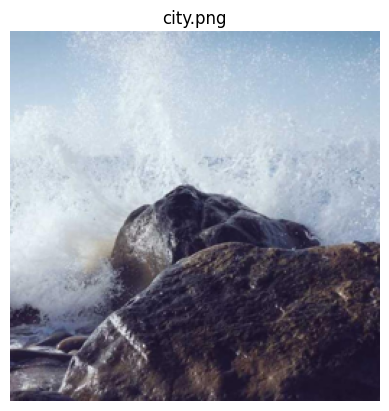

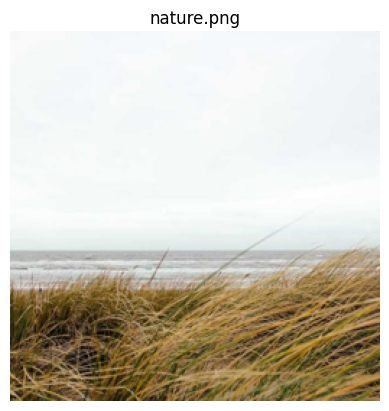

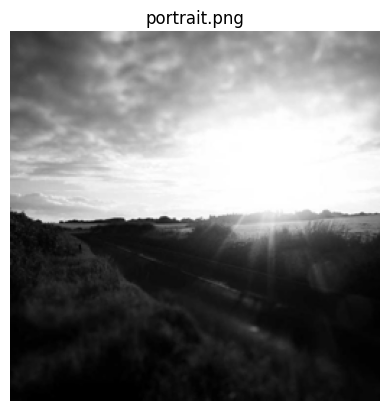

In [8]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

base = Path("/content/RePaint/my_samples/imgs")

# Convert all to 256×256 PNGs
for p in list(base.glob("*.jpg")) + list(base.glob("*.jpeg")) + list(base.glob("*.png")):
    im = Image.open(p).convert("RGB").resize((256, 256))
    out = base / f"{p.stem}.png"
    im.save(out)
    if p.suffix.lower() != ".png":
        p.unlink(missing_ok=True)

print("✅ Images ready:")
pngs = sorted(base.glob("*.png"))
for p in pngs:
    print(" -", p.name)

# Quick visual check
for p in pngs:
    im = Image.open(p)
    plt.figure()
    plt.imshow(im)
    plt.title(p.name)
    plt.axis("off")


✅ Masks created:
 - city_mask.png
 - nature_mask.png
 - portrait_mask.png


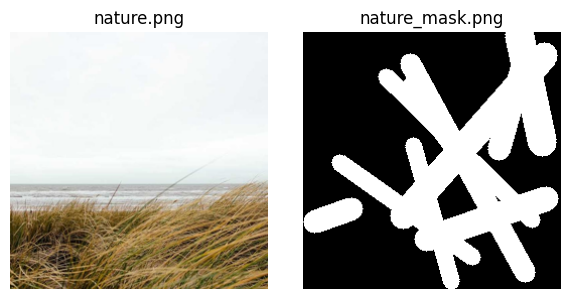

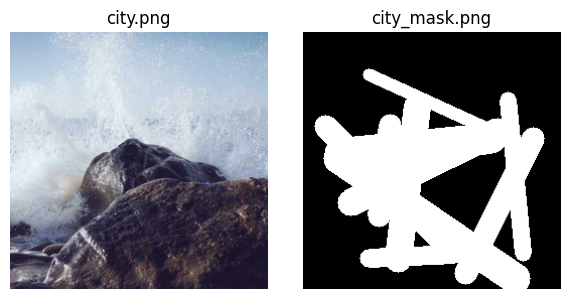

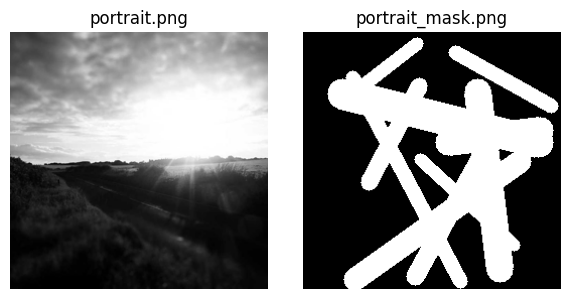

In [9]:
import numpy as np, cv2, random
from pathlib import Path

h, w = 256, 256
img_dir = Path("/content/RePaint/my_samples/imgs")
mask_dir = Path("/content/RePaint/my_samples/masks")
mask_dir.mkdir(parents=True, exist_ok=True)

def make_freeform_mask(seed, strokes=10, thickness_range=(10,30)):
    random.seed(seed)
    mask = np.zeros((h, w), np.uint8)
    for _ in range(strokes):
        x1, y1 = random.randint(0, w-1), random.randint(0, h-1)
        x2, y2 = random.randint(0, w-1), random.randint(0, h-1)
        th = random.randint(*thickness_range)
        cv2.line(mask, (x1, y1), (x2, y2), 255, th)
    return mask

# One mask per image
seeds = {"nature.png": 101, "city.png": 102, "portrait.png": 103}
for name, seed in seeds.items():
    m = make_freeform_mask(seed=seed, strokes=10)
    cv2.imwrite(str(mask_dir / f"{Path(name).stem}_mask.png"), m)

print("✅ Masks created:")
for p in sorted(mask_dir.glob("*.png")):
    print(" -", p.name)

# visual check
import matplotlib.pyplot as plt
from PIL import Image

for name in seeds.keys():
    img = Image.open(img_dir / name).convert("RGB")
    msk = Image.open(mask_dir / f"{Path(name).stem}_mask.png").convert("L")
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1); plt.imshow(img); plt.title(f"{name}"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(msk, cmap="gray"); plt.title(f"{Path(name).stem}_mask.png"); plt.axis("off")
    plt.tight_layout()


In [12]:
import os

os.makedirs("/content/RePaint/configs", exist_ok=True)

yaml_text = """# -------- Minimal config for RePaint inference --------
name: mytest_1
seed: 123

paths:
  image: my_samples/imgs/nature.png
  mask:  my_samples/masks/nature_mask.png
  outdir: outputs/mytest_1

model:
  type: ddpm
  ckpt: checkpoints/celeba256_ddpm.pth
  img_size: 256
  channels: 3

repaint:
  num_steps: 50
  jump_length: 5
  jump_n_sample: 5
  eta: 1.0

save:
  every_step: false
  final_only: true
"""

with open("/content/RePaint/configs/mytest.yaml", "w") as f:
    f.write(yaml_text)


print("✅ YAML file created successfully:")
!cat /content/RePaint/configs/mytest.yaml


✅ YAML file created successfully:
# -------- Minimal config for RePaint inference --------
name: mytest_1
seed: 123

paths:
  image: my_samples/imgs/nature.png
  mask:  my_samples/masks/nature_mask.png
  outdir: outputs/mytest_1

model:
  type: ddpm
  ckpt: checkpoints/celeba256_ddpm.pth
  img_size: 256
  channels: 3

repaint:
  num_steps: 50
  jump_length: 5
  jump_n_sample: 5
  eta: 1.0

save:
  every_step: false
  final_only: true


In [15]:
%cd /content/RePaint

# Install gdown and run the repo's downloader
!pip -q install --upgrade gdown
!bash ./download.sh

# See what got downloaded (models + example imgs/masks)
!ls -R


/content/RePaint
--2025-11-11 19:10:04--  https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_classifier.pt
Resolving openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)... 20.60.244.1
Connecting to openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)|20.60.244.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 216496432 (206M) [application/octet-stream]
Saving to: ‘256x256_classifier.pt’

256x256_classifier. 100%[===================>] 206.47M  2.62MB/s    in 78s     

2025-11-11 19:11:24 (2.63 MB/s) - ‘256x256_classifier.pt’ saved [216496432/216496432]

--2025-11-11 19:11:24--  https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion.pt
Resolving openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)... 20.60.244.1
Connecting to openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)|20.60.244.1|:443... connected.
HTTP request sent, awaiting respons

In [17]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/RePaint /content/drive/MyDrive/RePaint_backup



Mounted at /content/drive


In [18]:
%cd /content/RePaint
!python test.py --conf_path confs/face_example.yml \
  sampling.steps=50 repaint.jump_length=5 repaint.jump_n_sample=5


/content/RePaint
usage: test.py [-h] [--conf_path CONF_PATH]
test.py: error: unrecognized arguments: sampling.steps=50 repaint.jump_length=5 repaint.jump_n_sample=5


In [19]:
%cd /content/RePaint
!python test.py --conf_path confs/face_example.yml \
  sampling.steps=50 repaint.jump_length=5 repaint.jump_n_sample=5 \
  save.every_step=true


/content/RePaint
usage: test.py [-h] [--conf_path CONF_PATH]
test.py: error: unrecognized arguments: sampling.steps=50 repaint.jump_length=5 repaint.jump_n_sample=5 save.every_step=true


In [20]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA available: True
Device: Tesla T4


In [21]:
%cd /content/RePaint

!python test.py --config configs/mytest.yaml \
  repaint.num_steps=50 repaint.jump_length=5 repaint.jump_n_sample=5 \
  save.final_only=true save.every_step=false \
  paths.outdir=outputs/my_quick_run


/content/RePaint
usage: test.py [-h] [--conf_path CONF_PATH]
test.py: error: unrecognized arguments: --config configs/mytest.yaml repaint.num_steps=50 repaint.jump_length=5 repaint.jump_n_sample=5 save.final_only=true save.every_step=false paths.outdir=outputs/my_quick_run


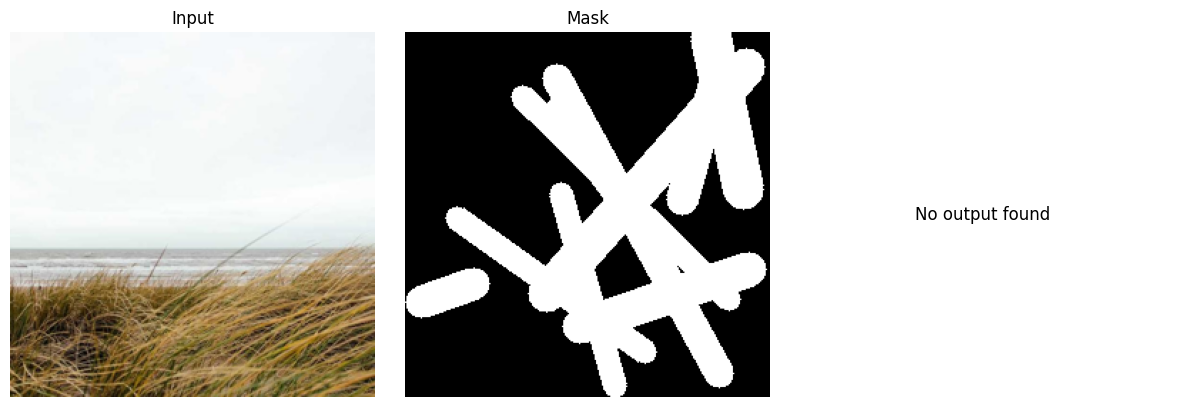

In [22]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

img_path = Path("/content/RePaint/my_samples/imgs/nature.png")
msk_path = Path("/content/RePaint/my_samples/masks/nature_mask.png")
out_dir  = Path("/content/RePaint/outputs/my_quick_run")

# Detect output file automatically
candidates = ["final.png", "sample.png", "output.png"]
out_path = next((out_dir / c for c in candidates if (out_dir / c).exists()), None)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(Image.open(img_path).convert("RGB")); axs[0].set_title("Input"); axs[0].axis("off")
axs[1].imshow(Image.open(msk_path).convert("L"), cmap="gray"); axs[1].set_title("Mask"); axs[1].axis("off")
if out_path:
    axs[2].imshow(Image.open(out_path).convert("RGB")); axs[2].set_title("Output"); axs[2].axis("off")
else:
    axs[2].text(0.5, 0.5, "No output found", ha="center", va="center", fontsize=12); axs[2].axis("off")
plt.tight_layout()


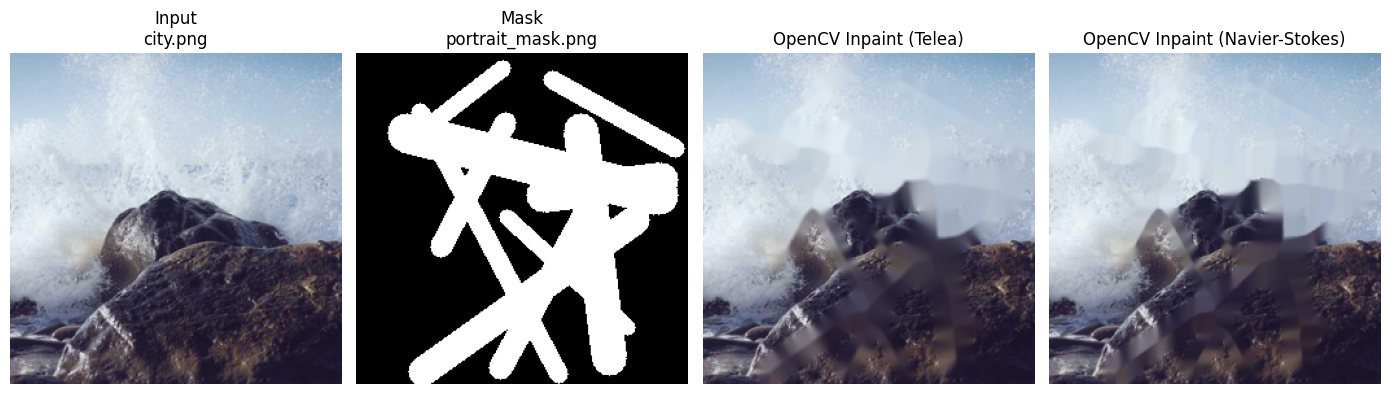

Saved to: /content/RePaint/outputs/week3_snapshot


In [43]:
# === Week-4 snapshot cell ===


import os, glob, cv2, numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def ensure_dir(p): os.makedirs(p, exist_ok=True); return p
def load_rgb(path, size=(256,256)):
    return np.array(Image.open(path).convert("RGB").resize(size, Image.LANCZOS))
def to_mask(path, size=(256,256)):
    m = Image.open(path).convert("L").resize(size, Image.NEAREST)
    m = (np.array(m) > 127).astype(np.uint8)*255
    return m
def demo_pair(size=(256,256)):
    w,h = size
    rgb = Image.new("RGB", size, (180,210,240))
    d = ImageDraw.Draw(rgb)
    d.rectangle([w*0.1, h*0.15, w*0.9, h*0.85], outline=(30,60,120), width=6)
    d.ellipse([w*0.35, h*0.25, w*0.65, h*0.55], fill=(240,180,120))
    d.rectangle([w*0.25, h*0.6, w*0.75, h*0.8], fill=(120,200,160))
    mask = Image.new("L", size, 0); dm = ImageDraw.Draw(mask)
    dm.rounded_rectangle([w*0.45, h*0.3, w*0.8, h*0.7], radius=18, fill=255)
    dm.ellipse([w*0.15, h*0.5, w*0.35, h*0.75], fill=255)
    return np.array(rgb), np.array(mask)

# Try to pick my prepared pair, else fall back to demo.
def first(globs):
    for g in globs:
        m = glob.glob(g);
        if m: return m[0]
    return None

img = first(["my_samples/imgs/*.png","my_samples/imgs/*.jpg","/mnt/data/my_samples/imgs/*.png"])
maskp = first(["my_samples/masks/*mask*.png","my_samples/masks/*.png","/mnt/data/my_samples/masks/*.png"])

if img and maskp:
    rgb = load_rgb(img); mask = to_mask(maskp)
    src_title, mask_title = f"Input\n{os.path.basename(img)}", f"Mask\n{os.path.basename(maskp)}"
else:
    rgb, mask = demo_pair(); src_title, mask_title = "Input (demo)", "Mask (demo)"

bgr = rgb[:, :, ::-1]
mask_u8 = (mask>0).astype(np.uint8)*255

telea = cv2.inpaint(bgr, mask_u8, 3, cv2.INPAINT_TELEA)
ns    = cv2.inpaint(bgr, mask_u8, 3, cv2.INPAINT_NS)

outdir = ensure_dir("outputs/week3_snapshot")
cv2.imwrite(os.path.join(outdir,"telea.png"), telea)
cv2.imwrite(os.path.join(outdir,"navier_stokes.png"), ns)

fig, axs = plt.subplots(1,4, figsize=(14,4))
axs[0].imshow(rgb); axs[0].set_title(src_title); axs[0].axis("off")
axs[1].imshow(mask_u8, cmap="gray"); axs[1].set_title(mask_title); axs[1].axis("off")
axs[2].imshow(telea[:,:,::-1]); axs[2].set_title("OpenCV Inpaint (Telea)"); axs[2].axis("off")
axs[3].imshow(ns[:,:,::-1]); axs[3].set_title("OpenCV Inpaint (Navier-Stokes)"); axs[3].axis("off")
plt.tight_layout(); plt.show()

print("Saved to:", os.path.abspath(outdir))
